<a href="https://colab.research.google.com/github/RHG117/telecom-analysis/blob/main/S7_Final_Project_ConnectaTel.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Análisis ConnectaTel

Como **analista de datos**, tu objetivo es evaluar el **comportamiento de los clientes** de una empresa de telecomunicaciones en Latinoamérica, ConnectaTel.

Trabajaremos con información registrada **hasta el año 2024**, lo cual permitirá analizar el comportamiento del negocio dentro de ese periodo.

Para ello trabajarás con tres datasets:  

- **plans.csv** → información de los planes actuales (precio, minutos incluidos, GB incluidos, costo por extra)  
- **users.csv** → información de los clientes (edad, ciudad, fecha de registro, plan, churn)  
- **usage.csv** → detalle del **uso real** de los servicios (llamadas y mensajes)  

Deberás **explorar**, **limpiar** y **analizar** estos datos para construir un **perfil estadístico** de los clientes, detectar **comportamientos atípicos** y crear **segmentos de clientes**.  

Este análisis te permitirá **identificar patrones de consumo**, **diseñar estrategias de retención** y **sugerir mejoras en los planes** ofrecidos por la empresa.

> 💡 Antes de empezar, recuerda pensar de forma **programática**: ¿qué pasos necesitas? ¿En qué orden? ¿Qué quieres medir y por qué?


---
## 🧩 Paso 1: Cargar y explorar

Antes de limpiar o combinar los datos, es necesario **familiarizarte con la estructura de los tres datasets**.  
En esta etapa, validarás que los archivos se carguen correctamente, conocerás sus columnas y tipos de datos, y detectarás posibles inconsistencias.

### 1.1 Carga de datos y vista rápida

**🎯 Objetivo:**  
Tener los **3 datasets listos en memoria**, entender su contenido y realizar una revisión preliminar.

**Instrucciones:**  
- Importa las librerías necesarias (por ejemplo `pandas`, `seaborn`, `matplotlib.pyplot`)
- Carga los archivos CSV usando `pd.read_csv()`:
  - **`/datasets/plans.csv`**  
  - **`/datasets/users_latam.csv`**  
  - **`/datasets/usage.csv`**  
- Guarda los DataFrames en las variables: `plans`, `users`, `usage`.  
- Muestra las primeras filas de cada DataFrame usando `.head()`.


In [31]:
# importar librerías
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

In [32]:
# cargar archivos
plans = pd.read_csv('plans.csv')
users = pd.read_csv('users_latam.csv')
usage = pd.read_csv('usage.csv')


In [33]:
# mostrar las primeras 5 filas de plans
plans.head()

,plan_name,messages_included,gb_per_month,minutes_included,usd_monthly_pay,usd_per_gb,usd_per_message,usd_per_minute
0,Basico,100,5,100,12,1.2,0.08,0.10
1,Premium,500,20,600,25,1.0,0.05,0.07


In [34]:
# mostrar las primeras 5 filas de users
users.head()

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date
0,10000,Carlos,Garcia,38,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN
1,10001,Mateo,Torres,53,?,2022-01-01 06:34:17.914478619,Basico,NaN
2,10002,Sofia,Ramirez,57,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN
3,10003,Mateo,Ramirez,69,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN
4,10004,Mateo,Torres,63,GDL,2022-01-02 02:17:11.657914478,Basico,NaN


In [35]:
# mostrar las primeras 5 filas de usage
usage.head()

,id,user_id,type,date,duration,length
0,1,10332,call,2024-01-01 00:00:00.000000000,0.09,NaN
1,2,11458,text,2024-01-01 00:06:30.969774244,NaN,39.0
2,3,11777,text,2024-01-01 00:13:01.939548488,NaN,36.0
3,4,10682,call,2024-01-01 00:19:32.909322733,1.53,NaN
4,5,12742,call,2024-01-01 00:26:03.879096977,4.84,NaN


**Tip:** Si no usas `print()` la tabla se vera mejor.

### 1.2 Exploración de la estructura de los datasets

**🎯 Objetivo:**  
Conocer la **estructura de cada dataset**, revisar cuántas filas y columnas tienen, identificar los **tipos de datos** de cada columna y detectar posibles **inconsistencias o valores nulos** antes de iniciar el análisis.

**Instrucciones:**  
- Revisa el **número de filas y columnas** de cada dataset usando `.shape`.  
- Usa `.info()` en cada DataFrame para obtener un **resumen completo** de columnas, tipos de datos y valores no nulos.  

In [36]:
# revisar el número de filas y columnas de cada dataset
print("plans", plans.shape)
print("users", users.shape)
print("usage", usage.shape)

plans (2, 8)
users (4000, 8)
usage (40000, 6)


In [37]:
# inspección de plans con .info()
plans.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2 entries, 0 to 1
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   plan_name          2 non-null      object 
 1   messages_included  2 non-null      int64  
 2   gb_per_month       2 non-null      int64  
 3   minutes_included   2 non-null      int64  
 4   usd_monthly_pay    2 non-null      int64  
 5   usd_per_gb         2 non-null      float64
 6   usd_per_message    2 non-null      float64
 7   usd_per_minute     2 non-null      float64
dtypes: float64(3), int64(4), object(1)
memory usage: 260.0+ bytes


In [38]:
# inspección de users con .info()
users.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   user_id     4000 non-null   int64 
 1   first_name  4000 non-null   object
 2   last_name   4000 non-null   object
 3   age         4000 non-null   int64 
 4   city        3531 non-null   object
 5   reg_date    4000 non-null   object
 6   plan        4000 non-null   object
 7   churn_date  466 non-null    object
dtypes: int64(2), object(6)
memory usage: 250.1+ KB


In [39]:
# inspección de usage con .info()
usage.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40000 entries, 0 to 39999
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        40000 non-null  int64  
 1   user_id   40000 non-null  int64  
 2   type      40000 non-null  object 
 3   date      39950 non-null  object 
 4   duration  17924 non-null  float64
 5   length    22104 non-null  float64
dtypes: float64(2), int64(2), object(2)
memory usage: 1.8+ MB


---

## 🧩Paso 2: Identificación de problemas de calidad de datos

### 2.1 Revisión de valores nulos

**🎯 Objetivo:**  
Detectar la presencia y magnitud de valores faltantes para evaluar si afectan el análisis o requieren imputación/eliminación.

**Instrucciones:**  
- Cuenta valores nulos por columna para cada dataset.
- Calcula la proporción de nulos por columna para cada dataset.

El dataset `plans` solamente tiene 2 renglones y se puede observar que no tiene ausentes, por ello no necesita exploración adicional.

<br>
<details>
<summary>Haz clic para ver la pista</summary>
Usa `.isna().sum()` para contar valores nulos y usa `.isna().mean()` para calcular la proporción.

In [40]:
# cantidad de nulos para users
print("=== NULOS EN USERS (conteo) ===")
print(users.isna().sum()) # Cantidad de valores nulos
print('\n')
print('=== NULOS EN USERS (proporción) ===')
print(users.isna().mean()) # Proporción de valores nulos

=== NULOS EN USERS (conteo) ===
user_id          0
first_name       0
last_name        0
age              0
city           469
reg_date         0
plan             0
churn_date    3534
dtype: int64


=== NULOS EN USERS (proporción) ===
user_id       0.00000
first_name    0.00000
last_name     0.00000
age           0.00000
city          0.11725
reg_date      0.00000
plan          0.00000
churn_date    0.88350
dtype: float64


In [41]:
# cantidad de nulos para usage
print("=== NULOS EN USAGE (conteo) ===")
print(usage.isna().sum()) # Cantidad de valores nulos
print('\n')
print('=== NULOS EN USAGE (proporción) ===')
print(usage.isna().mean()) # Proporción de valores nulos

=== NULOS EN USAGE (conteo) ===
id              0
user_id         0
type            0
date           50
duration    22076
length      17896
dtype: int64


=== NULOS EN USAGE (proporción) ===
id          0.00000
user_id     0.00000
type        0.00000
date        0.00125
duration    0.55190
length      0.44740
dtype: float64


✍️ **Comentario**: Haz doble clic en este bloque y escribe tu diagnóstico al final del bloque. Incluye qué ves y que acción recomendarías para cada caso.

💡 **Nota:** Justifica tus decisiones brevemente (1 línea por caso).
* Hint:
 - Si una columna tiene **más del 80–90% de nulos**, normalmente se **ignora o elimina**.  
 - Si tiene **entre 5% y 30%**, generalmente se **investiga para imputar o dejar como nulos**.  
 - Si es **menor al 5%**, suele ser un caso simple de imputación o dejar como nulos.

 ---

**Valores nulos**  
- ¿Qué columnas tienen valores faltantes y en qué proporción?  
- Indica qué harías: ¿imputar, eliminar, ignorar?

**Mis comentarios**
***City*** tiene un 11.7% de valores nulos - No es bajo, pero tampoco crítico.
Opciones: Imputar como "Unknown" / Mantener como categoría separada / Analizar si afecta churn

***churn_date*** → 88.35% pero este dato nos dice que ese porcentaje sigue activo (OK)

***duration*** y ***length*** estan divididos entre llamadas y mensajes, por eso ese porcentaje de nulos

In [42]:
usage.groupby("type")[["duration", "length"]].apply(lambda x: x.isna().mean())

,duration,length
type,,
call,0.000000,0.99933
text,0.999276,0.00000


In [43]:
usage.groupby("type")[["duration", "length"]].apply(lambda x: x.isna().sum())

,duration,length
type,,
call,0,17896
text,22076,0


### 2.2 Detección de valores inválidos y sentinels

🎯 **Objetivo:**  
Identificar sentinels: valores que no deberían estar en el dataset.

**Instrucciones:**
- Explora las columnas numéricas con **un resumen estadístico** y describe brevemente que encontraste.
- Explora las columnas categóricas **relevantes**, revisando sus valores únicos y describe brevemente que encontraste.


El dataset `plans` solamente tiene 2 renglones, por ello no necesita exploración adicional.

In [44]:
# explorar columnas numéricas de users
print("=== USERS ===")
print(users.describe())

=== USERS ===
            user_id          age
count   4000.000000  4000.000000
mean   11999.500000    33.739750
std     1154.844867   123.232257
min    10000.000000  -999.000000
25%    10999.750000    32.000000
50%    11999.500000    47.000000
75%    12999.250000    63.000000
max    13999.000000    79.000000


- La columna `user_id` muestra los usuarios desde el 10000 al 13999 (OK)
- La columna `age` tiene un sentinel --> -999 que esta afectando el promedio, debemos remplazarlo por NaN

In [45]:
# explorar columnas numéricas de usage
print("=== USAGE ===")
print(usage.describe())

=== USAGE ===
                id       user_id      duration        length
count  40000.00000  40000.000000  17924.000000  22104.000000
mean   20000.50000  12002.405975      5.202237     52.127398
std    11547.14972   1157.279564      6.842701     56.611183
min        1.00000  10000.000000      0.000000      0.000000
25%    10000.75000  10996.000000      1.437500     37.000000
50%    20000.50000  12013.000000      3.500000     50.000000
75%    30000.25000  13005.000000      6.990000     64.000000
max    40000.00000  13999.000000    120.000000   1490.000000


- Las columnas `id` y `user_id` estan OK
- Las columnas `duration` y `length` aunque tienen valores grandes son posibles y el valor 0 de una llamada podria ser por error de la misma llamda

In [46]:
# explorar columnas categóricas de users
columnas_user = ['city', 'plan']
print("=== USER (categoricas) ===")
print(users[columnas_user].describe())


=== USER (categoricas) ===
          city    plan
count     3531    4000
unique       7       2
top     Bogotá  Basico
freq       808    2595


- La columna `city` coincide con la revision anterior de un 11.7% de valores nulos, habría que imputar o marcarlos como Unknown
- La columna `plan` esta OK solo hay dos planes el Básico y el Premium

In [47]:
# explorar columna categórica de usage
print("=== USAGE (type) ===")
print(usage['type'].describe())

=== USAGE (type) ===
count     40000
unique        2
top        text
freq      22092
Name: type, dtype: object


- La columna `type` dos tipos, llamdas o mensajes (predominan los mensajes)


---
✍️ **Comentario**: Haz doble clic en este bloque y escribe tu diagnóstico. Incluye qué ves y que acción recomendarías para cada caso.

**Valores inválidos o sentinels**  
- ¿En qué columnas encontraste valores inválidos o sentinels?  
- ¿Qué acción tomarías?  

**Mis comentarios**
Se detectó un valor centinela (-999) en la columna age del dataset users, lo cual afecta significativamente la distribución estadística. Este valor será tratado como dato faltante.
Las variables duration y length en usage presentan valores nulos estructurales dependientes del tipo de evento (call/text), por lo que no se consideran errores.

### 2.3 Revisión y estandarización de fechas

**🎯 Objetivo:**  
Asegurar que las columnas de fecha estén correctamente formateadas y detectar años fuera de rango que indiquen errores de captura.

**Instrucciones:**  
- Convierte las columnas de fecha a tipo fecha y asegurate de que el código sea a prueba de errores.  
- Revisa cuántas veces aparece cada año.
- Identifica fechas imposibles (ej. años futuros o negativos).

Toma en cuenta que tenemos datos registrados hasta el año 2024.

In [48]:
# Convertir a fecha la columna `reg_date` de users
users['reg_date'] = pd.to_datetime(users["reg_date"], errors="coerce")

In [49]:
# Convertir a fecha la columna `date` de usage
usage['date'] = pd.to_datetime(usage["date"], errors="coerce")

In [50]:
# Revisar los años presentes en `reg_date` de users
print("=== REG_DATE años ===")
print(users["reg_date"].dt.year.value_counts())


=== REG_DATE años ===
reg_date
2024    1330
2023    1316
2022    1314
2026      40
Name: count, dtype: int64


En `reg_date`, hay 40 datos registrados como 2026, no es posible para este estudio, podriamos imputar

In [51]:
# Revisar los años presentes en `date` de usage
print("=== USAGE DATE años ===")
print(usage["date"].dt.year.value_counts())


=== USAGE DATE años ===
date
2024.0    39950
Name: count, dtype: int64


En `date`, falta la fecha para 50 datos

✍️ **Comentario**: escribe tu diagnóstico, e incluye **qué acción recomendarías** para cada caso:

**Fechas fuera de rango**  
- ¿Aparecen años imposibles? (años muy viejos o sin transcurrir al momento de guardar los datos)
- ¿Qué harías con ellas?

**Mis comentarios** Las columnas de fecha fueron convertidas correctamente a tipo datetime.
En usage.date no se encontraron inconsistencias; todos los registros pertenecen al año 2024.
Sin embargo, en users.reg_date se detectaron 40 registros con año 2026, lo cual es inconsistente dado que los datos disponibles llegan hasta 2024. Estos registros se consideran errores de captura y requieren corrección o tratamiento antes del análisis.

---

## 🧩Paso 3: Limpieza básica de datos

### 3.1 Corregir sentinels y fechas imposibles
**🎯 Objetivo:**  
Aplicar reglas de limpieza para reemplazar valores sentinels y corregir fechas imposibles.

**Instrucciones:**  
- En `age`, reemplaza el sentinel **-999** con la mediana.
- En `city`, reemplaza el sentinel `"?"` por valores nulos (`pd.NA`).  
- Marca como nulas (`pd.NA`) las fechas fuera de rango.

In [52]:
# Reemplazar -999 por la mediana de age
age_mediana = users['age'].median()
users['age'] = users['age'].replace(-999, age_mediana)

# Verificar cambios
users['age'].describe()

,age
count,4000.000000
mean,48.122250
std,17.690408
min,18.000000
25%,33.000000
50%,47.000000
75%,63.000000
max,79.000000


In [53]:
# Reemplazar ? por NA en city
users['city'] = users['city'].replace('?',pd.NA)

# Verificar cambios
users['city'].value_counts(dropna=False)

,count
city,
Bogotá,808
CDMX,730
Medellín,616
NaN,469
GDL,450
Cali,424
MTY,407
<NA>,96


In [54]:
# Marcar fechas futuras como NA para reg_date

users.loc[users['reg_date'].dt.year > 2024, 'reg_date'] = pd.NaT

# Verificar cambios

users['reg_date'].dt.year.value_counts()

,count
reg_date,
2024.0,1330
2023.0,1316
2022.0,1314


### 3.2 Corregir sentinels y fechas imposibles
**🎯 Objetivo:**  
Decidir qué hacer con los valores nulos según su proporción y relevancia.

**Instrucciones:**
- Verifica si los nulos en `duration` y `length` son **MAR**(Missing At Random) revisando si dependen de la columna `type`.  
  Si confirmas que son MAR, **déjalos como nulos** y justifica la decisión.



In [55]:
# Verificación MAR en usage (Missing At Random) para duration
# Ver el porcentaje de nulos en duration
print("Proporción de nulos:")
print(f"duration: {usage['duration'].isna().mean():.3f}")
# Analizar si los nulos en duration dependen de la columna type
print("\nProporción de nulos en 'duration' por tipo:")
duration_missing_by_type = usage['duration'].isna().groupby(usage['type']).mean()
print(duration_missing_by_type)


Proporción de nulos:
duration: 0.552

Proporción de nulos en 'duration' por tipo:
type
call    0.000000
text    0.999276
Name: duration, dtype: float64


In [56]:
# Verificación MAR en usage (Missing At Random) para length
# Ver el porcentaje de nulos en length
print("Proporción de nulos:")
print(f"length: {usage['length'].isna().mean():.3f}")
# Analizar si los nulos en length dependen de la columna type
print("\nProporción de nulos en 'length' por tipo:")
length_missing_by_type = usage['length'].isna().groupby(usage['type']).mean()
print(length_missing_by_type)

Proporción de nulos:
length: 0.447

Proporción de nulos en 'length' por tipo:
type
call    0.99933
text    0.00000
Name: length, dtype: float64


Haz doble clic aquíy escribe que tu diagnostico de nulos en `duration` y `length`

  **Mis comentarios**
Se analizó la proporción de valores nulos en `duration` y `length` segmentando por `type`.
Se observó que los valores faltantes dependen completamente del tipo de evento: las llamadas (call) solo presentan duración y los mensajes (text) solo presentan longitud.
Por lo tanto, los valores nulos son estructurales (no aplicables) y no corresponden a errores ni a datos faltantes aleatorios.
En consecuencia, se decidió mantenerlos como nulos.

---

## 🧩Paso 4: Summary statistics de uso por usuario


### 4.1 Agrupación por comportamiento de uso

🎯**Objetivo**: Resumir las variables clave de la tabla `usage` **por usuario**, creando métricas que representen su comportamiento real de uso histórico.

**Instrucciones:**:
1. Construye una tabla agregada de `usage` por `user_id` que incluya:
- número total de mensajes  
- número total de llamadas  
- total de minutos de llamadas

2. Renombra las columnas para que tengan nombres claros:  
- `cant_mensajes`  
- `cant_llamadas`  
- `cant_minutos_llamada`
3. Combina esta tabla con `users`.

In [57]:
usage.head(5)
# Columnas auxiliares
usage["is_text"] = (usage["type"] == "text").astype(int) #conocer el total de mensajes
usage["is_call"] = (usage["type"] == "call").astype(int) #conocer el total de llamadas


# Agrupar información por usuario
usage_agg = usage.groupby("user_id").agg({
    "is_text": "sum",        # total de mensajes
    "is_call": "sum",        # total de llamadas
    "duration": "sum"        # total de minutos de llamadas
}).reset_index()

# observar resultado
usage_agg.head(3)

,user_id,is_text,is_call,duration
0,10000,7,3,23.70
1,10001,5,10,33.18
2,10002,5,2,10.74


In [58]:
# Renombrar columnas
usage_agg.columns = ['user_id', 'cant_mensajes', 'cant_llamadas', 'cant_minutos_llamada']
# observar resultado
usage_agg.head(3)

,user_id,cant_mensajes,cant_llamadas,cant_minutos_llamada
0,10000,7,3,23.70
1,10001,5,10,33.18
2,10002,5,2,10.74


In [59]:
# Combinar la tabla agregada con el dataset de usuarios
user_profile = users.merge(usage_agg, on='user_id', how='left')
user_profile.head(5)

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_mensajes,cant_llamadas,cant_minutos_llamada
0,10000,Carlos,Garcia,38,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,7.0,3.0,23.70
1,10001,Mateo,Torres,53,<NA>,2022-01-01 06:34:17.914478619,Basico,NaN,5.0,10.0,33.18
2,10002,Sofia,Ramirez,57,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,5.0,2.0,10.74
3,10003,Mateo,Ramirez,69,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,11.0,3.0,8.99
4,10004,Mateo,Torres,63,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,4.0,3.0,8.01


### 4.2 4.2 Resumen estadístico por usuario durante el 2024

🎯 **Objetivo:** Analizar las columnas numéricas y categóricas de los usuarios, para identificar rangos, valores extremos y distribución de los datos antes de continuar con el análisis.

**Instrucciones:**  
1. Para las columnas **numéricas** relevantes, obtén un resumen estadístico (media, mediana, mínimo, máximo, etc.).  
2. Para la columna **categórica** `plan`, revisa la distribución en **porcentajes** de cada categoría.

In [60]:
# Resumen estadístico de las columnas numéricas
columnas_numericas = ['age','cant_mensajes', 'cant_llamadas', 'cant_minutos_llamada']

user_profile[columnas_numericas].describe()

,age,cant_mensajes,cant_llamadas,cant_minutos_llamada
count,4000.000000,3999.000000,3999.000000,3999.000000
mean,48.122250,5.524381,4.478120,23.317054
std,17.690408,2.358416,2.144238,18.168095
min,18.000000,0.000000,0.000000,0.000000
25%,33.000000,4.000000,3.000000,11.120000
50%,47.000000,5.000000,4.000000,19.780000
75%,63.000000,7.000000,6.000000,31.415000
max,79.000000,17.000000,15.000000,155.690000


In [61]:
# Distribución porcentual del tipo de plan
plan_summary = pd.DataFrame({
    'Conteo': user_profile['plan'].value_counts(),
    'Porcentaje': user_profile['plan'].value_counts(normalize=True) * 100
})
print(plan_summary.round(2))

         Conteo  Porcentaje
plan                       
Basico     2595       64.88
Premium    1405       35.12


---

## 🧩Paso 5: Visualización de distribuciones (uso y clientes) y outliers


### 5.1 Visualización de Distribuciones

🎯 **Objetivo:**  
Entender visualmente cómo se comportan las variables clave tanto de **uso** como de **clientes**, observar si existen diferencias según el tipo de plan, y analizar la **forma de la distribución**.

**Instrucciones:**  
Graficar **histogramas** para las siguientes columnas:  
- `age` (edad de los usuarios)
- `cant_mensajes`
- `cant_llamadas`
- `total_minutos_llamada`

Después de cada gráfico, escribe un **insight** respecto al plan y la variable, por ejemplo:  
- "Dentro del plan Premium, hay mayor proporción de..."  
- "Los usuarios Básico tienden a hacer ... llamadas y enviar ... mensajes."  o "No existe algún patrón."
- ¿Qué tipo de distribución tiene ? (simétrica, sesgada a la derecha o a la izquierda)

**Hint**  
Para cada histograma,
- Usa `hue='plan'` para ver cómo varían las distribuciones según el plan (Básico o Premium).
- Usa `palette=['skyblue','green']`
- Agrega título y etiquetas

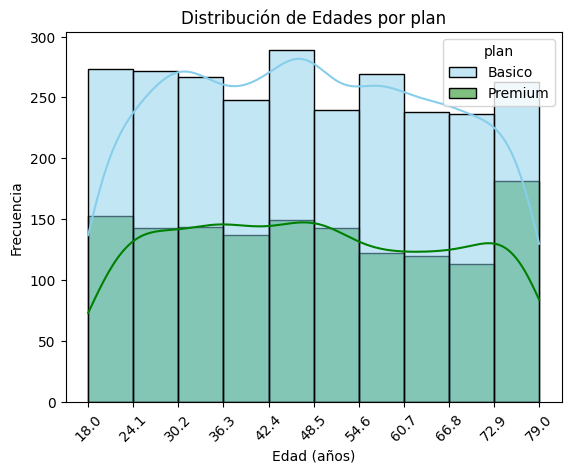

In [62]:
# Histograma para visualizar la edad (age)
counts, bin_edges = np.histogram(user_profile['age'], bins=10)
sns.histplot(user_profile, x='age', bins=bin_edges, hue='plan', palette=['skyblue','green'], kde=True, alpha=0.5)

# Agregar etiquetas y título
plt.xticks(bin_edges.round(1), rotation=45)
plt.xlabel('Edad (años)')
plt.ylabel('Frecuencia')
plt.title('Distribución de Edades por plan')
plt.show()

💡Insights:
- La distribución se ve:

Bastante uniforme / casi plana

No presenta una forma claramente normal

No hay sesgo fuerte ni a la derecha ni a la izquierda

No parece haber concentración fuerte en un rango específico de edad.

- El plan Básico tiene mayor cantidad de usuarios, aunque el plan premium tiene preferencia para clientes mayores de edad entre 72 y 79 años.

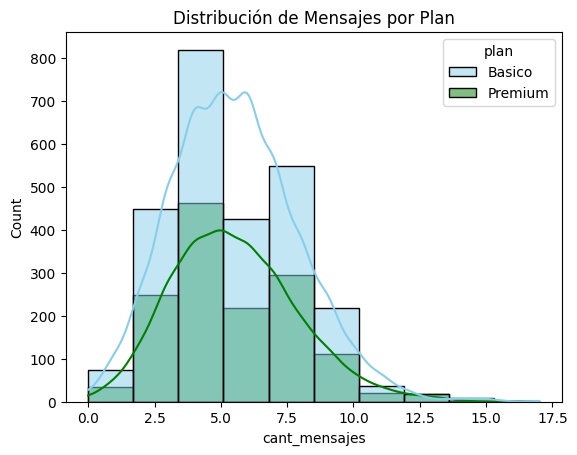

In [63]:
# Histograma para visualizar la cant_mensajes
sns.histplot(data=user_profile, x='cant_mensajes',palette=['skyblue','green'], hue='plan', bins=10, alpha=0.5, kde=True)
plt.title('Distribución de Mensajes por Plan')
plt.show()

💡Insights:
- La cantidad de mensajes presenta una distribución ligeramente sesgada a la derecha, concentrándose principalmente entre 3 y 5 mensajes.
- El plan Básico tiene mayor cantidad de mensajes con respecto al Premium.

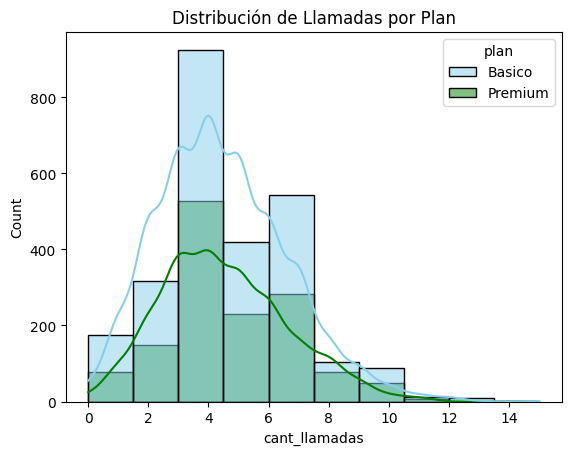

In [64]:
# Histograma para visualizar la cant_llamadas
sns.histplot(data=user_profile, x='cant_llamadas',palette=['skyblue','green'], hue='plan', bins=10, alpha=0.5, kde=True)
plt.title('Distribución de Llamadas por Plan')
plt.show()

💡Insights:
- La cantidad de llamadas presenta una distribución sesgada a la derecha, con la mayoría de los usuarios realizando entre 3 y 5 llamadas.
- De igual manera, el plan Básico tiene mayor frecuencia

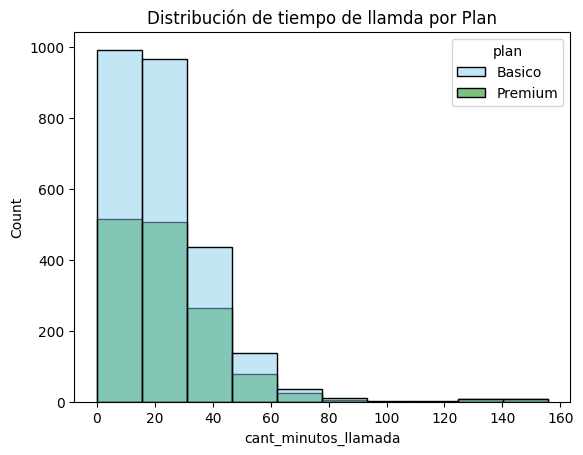

In [65]:
# Histograma para visualizar la cant_minutos_llamada
sns.histplot(data=user_profile, x='cant_minutos_llamada',palette=['skyblue','green'], hue='plan', bins=10, alpha=0.5)
plt.title('Distribución de tiempo de llamda por Plan')
plt.show()

💡Insights:
- El tiempo total de llamadas presenta una distribución fuertemente sesgada a la derecha, con una concentración importante en valores bajos y una cola larga hacia consumos elevados.
Se observa una ligera mayor dispersión en el plan Premium, lo que podría indicar que algunos usuarios de este plan tienden a realizar llamadas mas largas (más de 2 horas).

### 5.2 Identificación de Outliers

🎯 **Objetivo:**  
Detectar valores extremos en las variables clave de **uso** y **clientes** que podrían afectar el análisis, y decidir si requieren limpieza o revisión adicional.

**Instrucciones:**  
- Usa **boxplots** para identificar visualmente outliers en las siguientes columnas:  
  - `age`
  - `cant_mensajes`
  - `cant_llamadas`
  - `total_minutos_llamada`  
- Crea un **for** para generar los 4 boxplots automáticamente.
<br>

- Después de crear los gráfico, responde si **existen o no outliers** en las variables.  
- Si hay outliers, crea otro bucle para calcular los límites de esas columnas usando el **método IQR** y decide qué hacer con ellos.
  - Si solamente hay outliers de un solo lado, no es necesario calcular ambos límites.

**Hint:**
- Dentro del bucle, usa `plt.title(f'Boxplot: {col}')` para que el título cambie acorde a la columna.

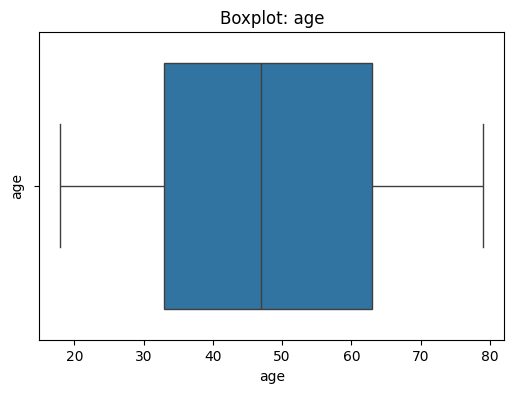

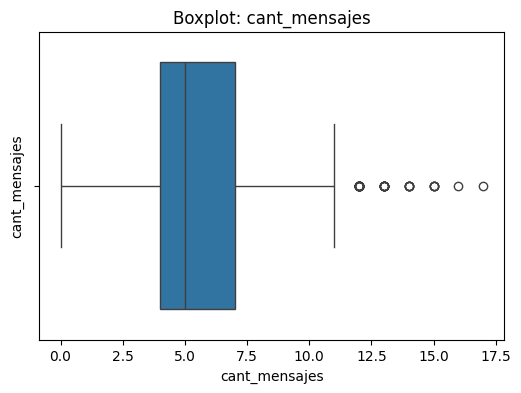

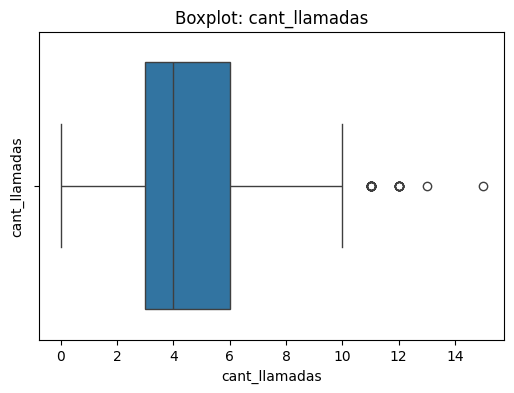

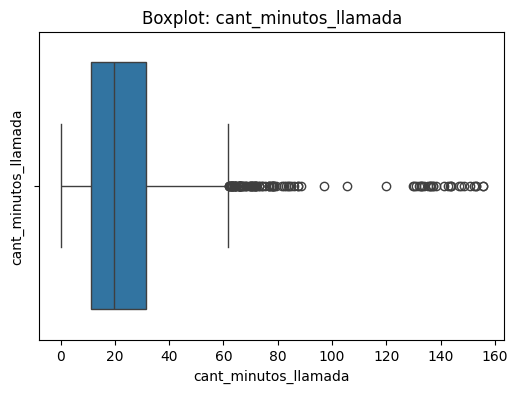

In [69]:
# Visualizando usando BoxPlot
columnas_numericas = ['age', 'cant_mensajes', 'cant_llamadas', 'cant_minutos_llamada']

for col in columnas_numericas:
  plt.figure(figsize=(6,4))
  sns.boxplot(data=user_profile, x=col)
  plt.title(f'Boxplot: {col}')
  plt.ylabel(col)
  plt.show()

💡Insights:
- Age: no presenta outliers, las edades quedan dentro de los bigotes
- cant_mensajes: Outliers por encima de 11 mensajes. Pero hay que analizar para saber si mantener, imputar o eliminar.
- cant_llamadas: Outliers por encima de 10 llamdas. Pero hay que analizar para saber si mantener, imputar o eliminar.
- cant_minutos_llamada: Outliers por encima de los 6o min. Pero hay que analizar para saber si mantener, imputar o eliminar.

In [ ]:
# Calcular límites con el método IQR
#columnas_limites = [...]



In [ ]:
# Revisa los limites superiores y el max, para tomar la decisión de mantener los outliers o no
#user_profile[columnas_limites].describe()

In [80]:
# Calcular límites con el método IQR
for col in columnas_numericas:

    Q1 = user_profile[col].quantile(0.25)
    Q3 = user_profile[col].quantile(0.75)
    IQR = Q3 - Q1

    lower_limit = Q1 - 1.5 * IQR
    upper_limit = Q3 + 1.5 * IQR

    print('==========================')
    print(f"\nVariable: {col}")
    print(f"Límite inferior: {lower_limit}")
    print(f"Límite superior: {upper_limit}")

    outliers = user_profile[(user_profile[col] < lower_limit) |
                            (user_profile[col] > upper_limit)]

    print(f"Cantidad de outliers: {len(outliers)}")
    print()
    print(outliers[col].describe())


Variable: age
Límite inferior: -12.0
Límite superior: 108.0
Cantidad de outliers: 0

count    0.0
mean     NaN
std      NaN
min      NaN
25%      NaN
50%      NaN
75%      NaN
max      NaN
Name: age, dtype: float64

Variable: cant_mensajes
Límite inferior: -0.5
Límite superior: 11.5
Cantidad de outliers: 46

count    46.000000
mean     12.891304
std       1.251280
min      12.000000
25%      12.000000
50%      12.000000
75%      13.000000
max      17.000000
Name: cant_mensajes, dtype: float64

Variable: cant_llamadas
Límite inferior: -1.5
Límite superior: 10.5
Cantidad de outliers: 30

count    30.000000
mean     11.466667
std       0.860366
min      11.000000
25%      11.000000
50%      11.000000
75%      12.000000
max      15.000000
Name: cant_llamadas, dtype: float64

Variable: cant_minutos_llamada
Límite inferior: -19.322500000000005
Límite superior: 61.8575
Cantidad de outliers: 109

count    109.000000
mean      90.626789
std       32.007619
min       62.110000
25%       66.0800

💡Insights:
- cant_mensajes: mantener los outliers, ya que solo son +6 mensajes no marcan una gran diferencia, su desviacion es de 1.25 (muy baja) es normal considerar hasta 17 mensajes.
- cant_llamadas: mantener los outliers, el promedio de estos se mantiene en 11 llamadas (nada exajerado) y su desviacion es muy baja (0.86), querindo decir que es un valor posible.
- cant_minutos_llamada: quiza dederiamos de imputar estos outliers con el valor minimo de estos mismos (62.11 minutos) o incluso con el Q1 (66.08 minutos)

In [83]:
#Usando Z-method para cant_minutos_llamadas
promedio_cml = user_profile['cant_minutos_llamada'].mean()
std = user_profile['cant_minutos_llamada'].std()
user_profile['z'] = (user_profile['cant_minutos_llamada']-promedio_cml) / std
user_profile[user_profile['z'].abs() > 3]
user_profile['z'].describe()

,z
count,3.999000e+03
mean,9.061685e-17
std,1.000000e+00
min,-1.283407e+00
25%,-6.713447e-01
50%,-1.946849e-01
75%,4.457234e-01
max,7.286011e+00


In [87]:
#Usando Z-method para age
promedio_cml = user_profile['age'].mean()
std = user_profile['age'].std()
user_profile['z'] = (user_profile['age']-promedio_cml) / std
user_profile[user_profile['z'].abs() > 3]
print(user_profile['z'].describe())

count    4.000000e+03
mean    -6.572520e-17
std      1.000000e+00
min     -1.702745e+00
25%     -8.548276e-01
50%     -6.343833e-02
75%      8.410066e-01
max      1.745452e+00
Name: z, dtype: float64


---

## 🧩Paso 6: Segmentación de Clientes

### 6.1 Segmentación de Clientes Por Uso

🎯 **Objetivo:** Clasificar a cada usuario en un grupo de uso (Bajo uso, Uso medio, Alto uso) basándose en la cantidad de llamadas y mensajes registrados.

**Instrucciones:**  
- Crea una nueva columna llamada `grupo_uso` en el dataframe `user_profile`.
- Usa comparaciones lógicas (<, >) para evaluar las condiciones de llamadas y mensajes y asigna:
  - `'Bajo uso'` cuando llamadas < 5 y mensajes < 5
  - `'Uso medio'` cuando llamadas < 10 y mensajes < 10
  - `'Alto uso'` para el resto de casos

In [90]:
# Crear columna grupo_uso
user_profile['grupo_uso'] = np.where(
    (user_profile['cant_llamadas'] < 5) & (user_profile['cant_mensajes'] < 5),
      'Bajo uso',
          np.where(
              (user_profile['cant_llamadas'] < 10) & (user_profile['cant_mensajes'] < 10),
                   'Uso medio',
    'Alto uso')
)



In [91]:
# verificar cambios
user_profile.head()

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_mensajes,cant_llamadas,cant_minutos_llamada,z,grupo_uso
0,10000,Carlos,Garcia,38,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,7.0,3.0,23.70,-0.572189,Uso medio
1,10001,Mateo,Torres,53,<NA>,2022-01-01 06:34:17.914478619,Basico,NaN,5.0,10.0,33.18,0.275729,Alto uso
2,10002,Sofia,Ramirez,57,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,5.0,2.0,10.74,0.501840,Uso medio
3,10003,Mateo,Ramirez,69,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,11.0,3.0,8.99,1.180173,Alto uso
4,10004,Mateo,Torres,63,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,4.0,3.0,8.01,0.841007,Bajo uso


### 6.2 Segmentación de Clientes Por Edad

🎯 **Objetivo:**: Clasificar a cada usuario en un grupo por **edad**.

**Instrucciones:**  
- Crea una nueva columna llamada `grupo_edad` en el dataframe `user_profile`.
- Usa comparaciones lógicas (<, >) para evaluar las condiciones y asigna:
  - `'Joven'` cuando age < 30
  - `'Adulto'` cuando age < 60
  - `'Adulto Mayor'` para el resto de casos

In [92]:
# Crear columna grupo_edad
user_profile['grupo_edad'] = np.where(
    (user_profile['age'] < 30),
      'Joven',
          np.where(
              (user_profile['age'] < 60),
                   'Adulto',
    'Adulto mayor')
)



In [93]:
# verificar cambios
user_profile.head()

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_mensajes,cant_llamadas,cant_minutos_llamada,z,grupo_uso,grupo_edad
0,10000,Carlos,Garcia,38,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,7.0,3.0,23.70,-0.572189,Uso medio,Adulto
1,10001,Mateo,Torres,53,<NA>,2022-01-01 06:34:17.914478619,Basico,NaN,5.0,10.0,33.18,0.275729,Alto uso,Adulto
2,10002,Sofia,Ramirez,57,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,5.0,2.0,10.74,0.501840,Uso medio,Adulto
3,10003,Mateo,Ramirez,69,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,11.0,3.0,8.99,1.180173,Alto uso,Adulto mayor
4,10004,Mateo,Torres,63,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,4.0,3.0,8.01,0.841007,Bajo uso,Adulto mayor


### 6.3 Visualización de la Segmentación de Clientes

🎯 **Objetivo:** Visualizar la distribución de los usuarios según los grupos creados: **grupo_uso** y **grupo_edad**.

**Instrucciones:**  
- Crea dos gráficos para las variables categóricas `grupo_uso` y `grupo_edad`.
- Agrega título y etiquetas a los ejes en cada gráfico.

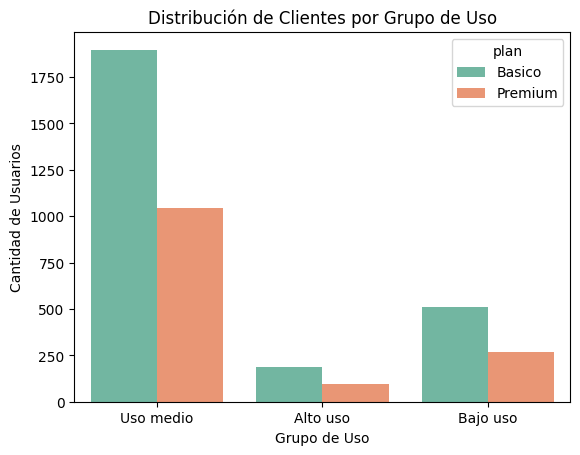

In [120]:
# Visualización de los segmentos por uso
sns.countplot(data=user_profile, x='grupo_uso', palette='Set2', hue='plan')

plt.title('Distribución de Clientes por Grupo de Uso')
plt.xlabel('Grupo de Uso')
plt.ylabel('Cantidad de Usuarios')
plt.show()

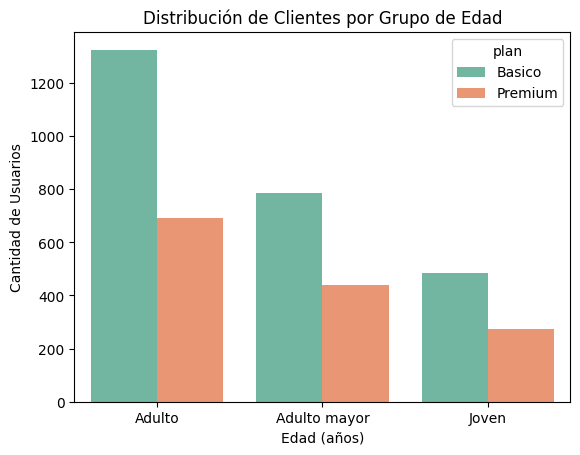

In [119]:
# Visualización de los segmentos por edad
sns.countplot(data=user_profile, x='grupo_edad', palette='Set2', hue='plan')

plt.title('Distribución de Clientes por Grupo de Edad')
plt.xlabel('Edad (años)')
plt.ylabel('Cantidad de Usuarios')
plt.show()


---
## 🧩Paso 7: Insight Ejecutivo para Stakeholders

🎯 **Objetivo:** Traducir los hallazgos del análisis en conclusiones accionables para el negocio, enfocadas en segmentación, patrones de uso y oportunidades comerciales.

**Preguntas a responder:**
- ¿Qué problemas tenían originalmemte los datos?¿Qué porcentaje, o cantidad de filas, de esa columna representaban?


- ¿Qué segmentos de clientes identificaste y cómo se comportan según su edad y nivel de uso?  
- ¿Qué segmentos parecen más valiosos para ConnectaTel y por qué?  
- ¿Qué patrones de uso extremo (outliers) encontraste y qué implican para el negocio?


- ¿Qué recomendaciones harías para mejorar la oferta actual de planes o crear nuevos planes basados en los segmentos y patrones detectados?

✍️ **Escribe aquí tu análisis ejecutivo:**

### Análisis ejecutivo

⚠️ **Problemas detectados en los datos**

Durante la fase de exploración se identificaron los siguientes problemas:


Marca como nulas (pd.NA) las fechas fuera de rango.

1. En `age`, se reemplazo el sentinel `-999` con la mediana.

2. Existencia de valores nulos en variables de uso (mensajes, llamadas y minutos), principalmente asociados la variable de `type`

3. Presencia de valores faltantes en la variable ciudad. En `city` teniamos un 11.7% de valores nulos, reemplazamos el sentinel `"?"` por valores nulos (pd.NA).

4. Se cambio a tipo de fecha las columnas `reg_date`y `date` y  se marco como nulas (pd.NA) las fechas fuera de rango (fechas de 2026).

5. Distribuciones sesgadas a la derecha en variables de consumo (especialmente minutos de llamada).

6. Identificación de valores extremos (outliers) en minutos de llamada.

En general, los datos eran utilizables tras una limpieza básica y validación de coherencia.


🔍 **Segmentos por Edad**

Se identificaron tres segmentos:

- Joven (menor a 30 años)
- Adulto (entre 30 y 60 años)
- Adulto mayor (mayor a 60 años)

Hallazgos clave:

El segmento Adulto concentra la mayor cantidad de clientes. Por encima de 1200 usuarios en el plan básico.

Le sigue Adulto mayor, mientras que Joven representa la menor proporción.


📊 **Segmentos por Nivel de Uso**
Se segmentaron los clientes en:
- Bajo uso cuando llamadas < 5 y mensajes < 5
- Uso medio cuando llamadas < 10 y mensajes < 10
- Alto uso para el resto de casos

Hallazgos clave:

La mayoría de los usuarios pertenece al grupo de Uso medio, con un amayoria de 1750 usuarios en el plan Básico.

El grupo de Alto uso es minoritario, pero estratégicamente relevante.

Las variables de uso presentan sesgo a la derecha, especialmente en minutos de llamada (con llamadas de mas de 60 minutos).

Los usuarios de alto uso tienden a concentrar una parte importante del consumo total.

➡️ Esto sugiere que el consumo no está distribuido uniformemente: un grupo reducido de usuarios concentra gran parte del uso, lo cual tiene implicaciones en rentabilidad y diseño de planes.


💡 **Recomendaciones**

1. Patrones de Uso Extremo (Outliers)
Se detectaron valores extremos principalmente en:
- Minutos totales de llamada

Estos usuarios presentan consumo significativamente superior al promedio.
Implicaciones:
No parecen errores de captura. Representan usuarios intensivos.
Pueden ser altamente rentables.
Este segmento puede representar una oportunidad para planes premium especializados o paquetes ilimitados.

2. Diseñar un plan enfocado en Alto uso

-Plan con mayor capacidad de minutos.

-Beneficios diferenciados.

-Posible estrategia de upselling desde Uso medio.

3. Optimizar el plan Básico

-La mayoría de clientes pertenece a Uso medio.

-Ajustar beneficios para evitar fuga hacia competidores.

4. Estrategia de segmentación basada en comportamiento, no edad

-La edad no es variable diferenciadora.

-El nivel de uso es mejor criterio para personalización.

**Estrategia comercial**

Bajo uso → planes económicos con beneficios digitales.

Uso medio → plan estándar optimizado.

Alto uso → plan premium o ilimitado.

---

## 🧩Paso 8 Cargar tu notebook y README a GitHub

🎯 **Objetivo:**  
Entregar tu análisis de forma **profesional**, **documentada** y **versionada**, asegurando que cualquier persona pueda revisar, ejecutar y entender tu trabajo.



### Opción A : Subir archivos desde la interfaz de GitHub (UI)

1. Descarga este notebook (`File → Download .ipynb`).  
2. Entra a tu repositorio en GitHub (por ejemplo `telecom-analysis` o `sprint7-final-project`).  
3. Sube tu notebook **Add file → Upload files**.  

---

### Opción B : Guardar directo desde Google Colab

1. Abre tu notebook en Colab.  
2. Ve a **File → Save a copy in GitHub**.  
3. Selecciona el repositorio y la carpeta correcta (ej: `notebooks/`).  
4. Escribe un mensaje de commit claro, por ejemplo:  
    - `feat: add final ConnectaTel analysis`
    - `agregar version final: Análisis ConnectaTel`
5. Verifica en GitHub que el archivo quedó en el lugar correcto y que el historial de commits se mantenga limpio.

---

Agrega un archivo `README.md` que describa de forma clara:
- el objetivo del proyecto,  
- los datasets utilizados,  
- las etapas del análisis realizadas,  
- cómo ejecutar el notebook (por ejemplo, abrirlo en Google Colab),  
- una breve guía de reproducción.
---

Link a repositorio público del proyecto: `LINK a tu repo aquí`